<a href="https://colab.research.google.com/github/SeiDra/lending-club-prediction/blob/scindage-du-notebook-FeatureEngineering%2FModeling/du_sda_ml2_P4_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROJET 7 : Loan Default Prediction
Partie N°4 — Modélisation & Évaluation

Contenu :
- Import des données transformées (sortie du P3)
- Gestion du déséquilibre via LightGBM (is_unbalanced=True)
- Feature Selection
- Évaluation LightGBM (Cross-Validation 5-fold)
- Optimisation du modèle
- Évaluation finale sur le Test Set (une seule fois)
- Interprétabilité et conclusions

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as sps
import seaborn as sns

from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, f1_score, precision_score,
                              recall_score, roc_auc_score, roc_curve,
                              precision_recall_curve)
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

In [13]:
train_X = pd.read_parquet("DATA/03_train_X.parquet")
train_y = pd.read_parquet("DATA/03_train_y.parquet").squeeze()
test_X = pd.read_parquet("DATA/03_test_X.parquet")
test_y = pd.read_parquet("DATA/03_test_y.parquet").squeeze()

# Lecture du nom de la cible (pour les fonctions utilitaires)
with open("CONFIG/target_config.txt", "r") as f:
    target_col = f.read().strip()

print(f"Train X : {train_X.shape} | Train y : {train_y.shape}")
print(f"Test  X : {test_X.shape}  | Test  y : {test_y.shape}")
print(f"\nRatio défaut train : {train_y.mean():.2%}")
print(f"Ratio défaut test  : {test_y.mean():.2%}")

Train X : (1166919, 86) | Train y : (1166919,)
Test  X : (291730, 86)  | Test  y : (291730,)

Ratio défaut train : 19.00%
Ratio défaut test  : 19.00%


In [14]:
# Pas de sous-échantillonnage : on conserve toutes les données d'entraînement
train_X_model = train_X.copy()
train_y_model = train_y.copy()

print(f"Train complet : {train_X_model.shape}")
print(train_y_model.value_counts())

Train complet : (1166919, 86)
loan_condition_int
0    945227
1    221692
Name: count, dtype: int64


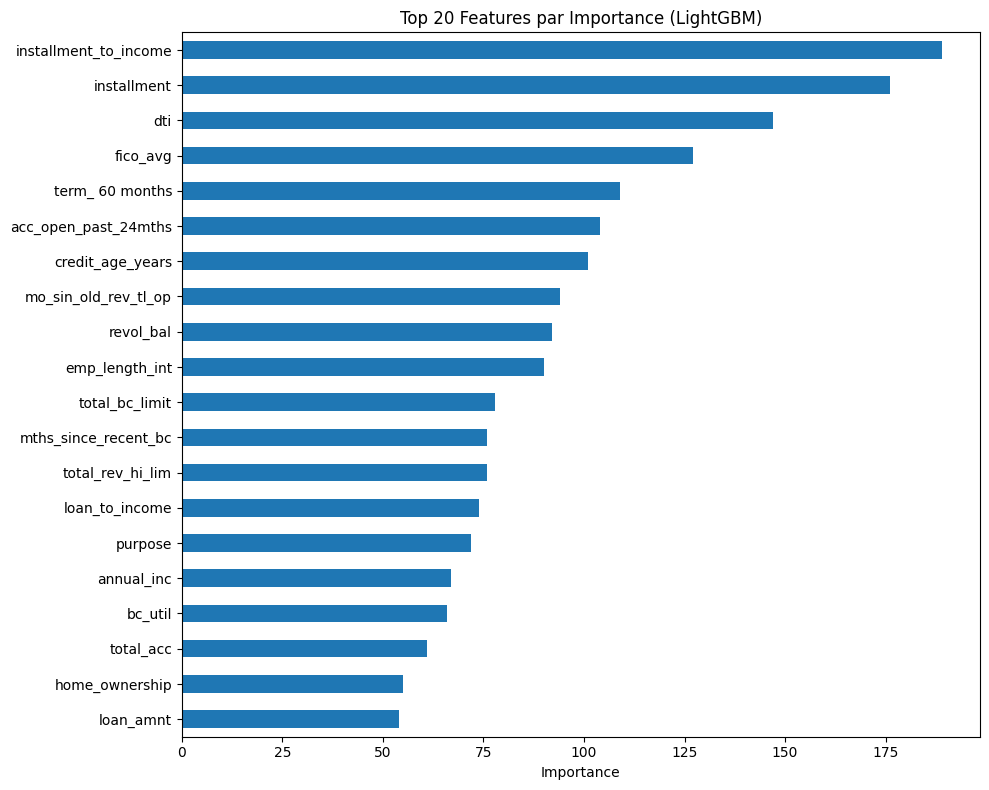


15 features retenues : ['installment_to_income', 'installment', 'dti', 'fico_avg', 'term_ 60 months', 'acc_open_past_24mths', 'credit_age_years', 'mo_sin_old_rev_tl_op', 'revol_bal', 'emp_length_int', 'total_bc_limit', 'mths_since_recent_bc', 'total_rev_hi_lim', 'loan_to_income', 'purpose']


In [15]:
# Méthode : Feature Importance via un modèle LightGBM rapide
from lightgbm import LGBMClassifier

# Entraîner un modèle rapide pour obtenir les importances
lgbm_quick = LGBMClassifier(
    n_estimators=100,
    random_state=42,
    verbose=-1,
    is_unbalanced=True
)
lgbm_quick.fit(train_X_model, train_y_model)

# Extraire et afficher les importances
importances = pd.Series(lgbm_quick.feature_importances_, index=train_X_model.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importances.head(20).plot(kind='barh')
plt.title("Top 20 Features par Importance (LightGBM)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Sélectionner les features avec importance > 0 (ou un seuil personnalisé)
N_TOP_FEATURES = 15
vars_final = importances.head(N_TOP_FEATURES).index.tolist()
print(f"\n{N_TOP_FEATURES} features retenues : {vars_final}")

# Filtrer train et test
train_X_selected = train_X_model[vars_final]
test_X_selected = test_X[vars_final]

In [ ]:
# Optimisation de LightGBM avec RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10, -1],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'num_leaves': [15, 31, 63, 127],
    'min_child_samples': [10, 20, 50],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
}

search = RandomizedSearchCV(
    LGBMClassifier(random_state=42, verbose=-1, is_unbalanced=True),
    param_distributions=param_dist,
    n_iter=30,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='average_precision',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Entraîner sur le jeu d'entraînement complet (features sélectionnées)
search.fit(train_X_selected, train_y_model)

print(f"\nMeilleurs paramètres : {search.best_params_}")
print(f"Meilleure Average Precision (CV) : {search.best_score_:.4f}")

best_model = search.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Meilleurs paramètres : {'subsample': 0.8, 'num_leaves': 63, 'n_estimators': 500, 'min_child_samples': 20, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Meilleur AUC (CV) : 0.7044


RAPPORT DE CLASSIFICATION FINAL (TEST SET)
              precision    recall  f1-score   support

   Good Loan       0.82      0.99      0.89    236307
    Bad Loan       0.54      0.04      0.08     55423

    accuracy                           0.81    291730
   macro avg       0.68      0.52      0.49    291730
weighted avg       0.76      0.81      0.74    291730



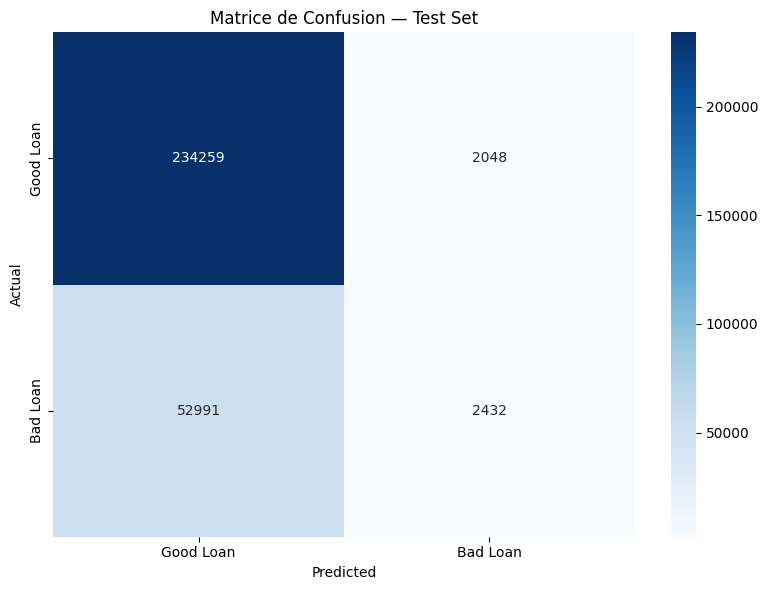

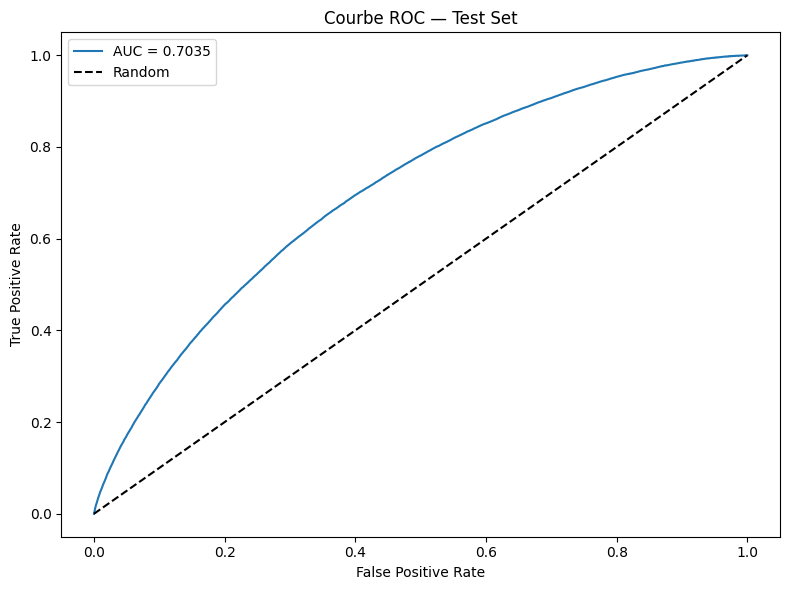

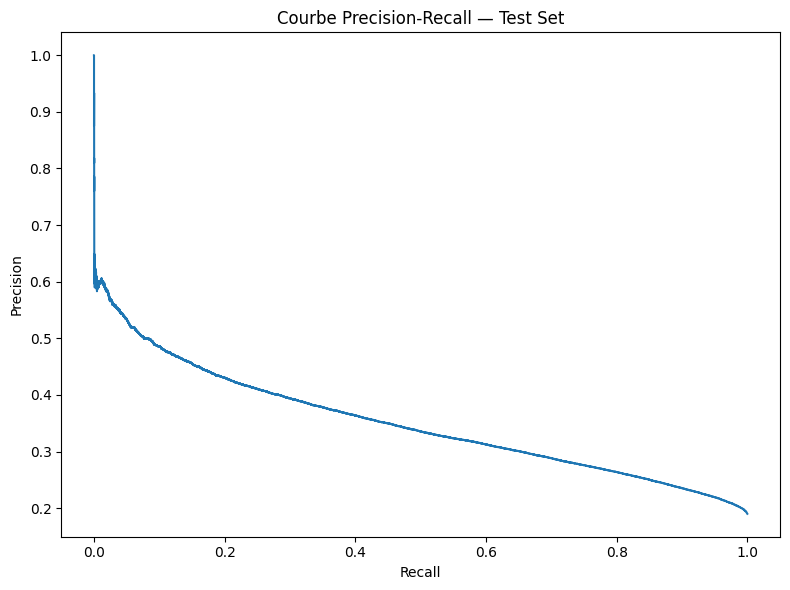


RÉSUMÉ COMPLET DES MÉTRIQUES - TEST SET

📊 MÉTRIQUES GLOBALES
--------------------------------------------------------------------------------
Accuracy                : 0.8113
AUC-ROC                 : 0.7035
KS Statistic            : 0.2960

📈 MÉTRIQUES PAR CLASSE
--------------------------------------------------------------------------------
Classe               Precision       Recall          F1-Score       
-------------------- --------------- --------------- ---------------
Good Loan (0)        0.8155         0.9913         0.8949
Bad Loan (1)         0.5429         0.0439         0.0812

📊 MOYENNES GLOBALES
--------------------------------------------------------------------------------
Métrique             Macro Avg            Weighted Avg        
-------------------- -------------------- --------------------
Precision            0.6792        0.7637
Recall               0.5176        0.8113
F1-Score             0.4880        0.7403


📋 TABLEAU RÉCAPITULATIF
       Class  Prec

In [ ]:
from sklearn.metrics import fbeta_score, average_precision_score

# On établit l'évaluation finale sur le test set
y_pred = best_model.predict(test_X_selected)
y_pred_proba = best_model.predict_proba(test_X_selected)[:, 1]

# Calcul des métriques essentielles
recall_classe1 = recall_score(test_y, y_pred)
f2_score = fbeta_score(test_y, y_pred, beta=2)
auprc = average_precision_score(test_y, y_pred_proba)

# KS Statistic
mask = test_y.astype(bool).values
ks_stat = sps.ks_2samp(y_pred_proba[mask], y_pred_proba[~mask])[0]

print("=" * 60)
print("RÉSUMÉ DES MÉTRIQUES CLÉS - TEST SET")
print("=" * 60)
print(f"🔹 AUPRC (Average Precision) : {auprc:.4f} → Robustesse globale du modèle (indépendant du déséquilibre).")
print(f"🔹 Recall (Classe 1)         : {recall_classe1:.4f} → Protection du capital : taux de détection des vrais défauts.")
print(f"🔹 F2-Score                  : {f2_score:.4f} → Métrique métier : accorde 2x plus de poids au Recall qu'à la Précision.")
print(f"🔹 KS Statistic              : {ks_stat:.4f} → Séparation des distributions (Bon vs Mauvais crédit).")
print("=" * 60)

# Courbe Precision-Recall (pour appui visuel de l'AUPRC)
precision_curve, recall_curve, _ = precision_recall_curve(test_y, y_pred_proba)
plt.figure(figsize=(6, 4))
plt.plot(recall_curve, precision_curve, label=f'AUPRC = {auprc:.4f}', color='darkorange')
plt.xlabel('Recall (Détection des défauts)')
plt.ylabel('Precision (Fiabilité de l\'alerte)')
plt.title('Courbe Precision-Recall — Test Set')
plt.legend()
plt.tight_layout()
plt.show()

# Matrice de confusion rapide (pour la lisibilité)
cm = confusion_matrix(test_y, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Good', 'Bad'], yticklabels=['Good', 'Bad'])
plt.xlabel('Prédiction')
plt.ylabel('Réalité')
plt.title('Matrice de Confusion')
plt.tight_layout()
plt.show()

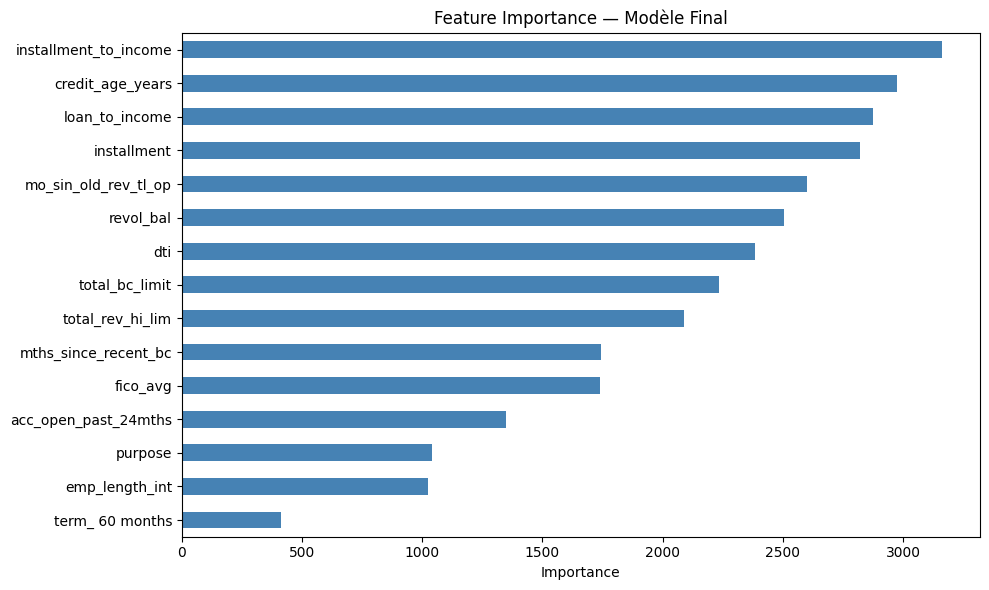

In [20]:
# Feature Importance du modèle final
importances_final = pd.Series(best_model.feature_importances_,
                               index=test_X_selected.columns)
importances_final = importances_final.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances_final.plot(kind='barh', color='steelblue')
plt.title("Feature Importance — Modèle Final")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [21]:
# (Optionnel) SHAP Values
# import shap
# explainer = shap.TreeExplainer(best_model)
# shap_values = explainer.shap_values(test_X_selected)
# shap.summary_plot(shap_values[1], test_X_selected)

In [22]:
# Conclusions et Recommandations
# Résumer :
# 1. Les performances du modèle final (AUC, F1, KS, etc.)
# 2. Les 5 variables les plus influentes et leur interprétation métier
# 3. Les recommandations concrètes pour l'institution financière
# 4. Les limites du modèle et les pistes d'amélioration